In [1]:
import numpy as np
import time
from dataclasses import dataclass
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [2]:
train = np.load("../data/processed/TRAIN_30.npz", allow_pickle=True)
X_train = train["X"][::20]
y_train = train["y"][::20]

full = np.load("../data/processed/FULL_30.npz", allow_pickle=True)
X_full  = full["X"][::10]
K0_full = full["K0"][::10]

In [3]:
def build_model(base_model):
    pipe = Pipeline([
        # ("scaler", StandardScaler()),
        ("clf", base_model)
    ])
    return pipe

def run_supervised_pipeline(model, X_train, y_train, X_full):
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)

    if hasattr(model, "predict_proba"):
        print("pipipupu")
        print("Train_score: ", train_score)
        print(model.classes_)
        P_A = model.predict_proba(X_full)[:, 1]
    else:
        print("pupupipi")
        scores = model.decision_function(X_full)
        P_A = 1.0 / (1.0 + np.exp(-scores))

    return train_score, P_A


In [4]:
#          Decision Tree      4.78          5.031
#          Gradient Boosted Trees      4.78         13.629
#             Logistic Regression      4.78          5.195
# Logistic Regression C = 0.00175      4.77          6.104
#                  Neural Network      4.78          6.725
#                   Random Forest      4.78          7.357
#                       SVM (RBF)      4.77         19.295
#                             kNN      4.77        102.078
models_477 = {
    "Logistic Regression C = 0.00175": LogisticRegression(C=0.00175),
    "kNN 51 - distance": KNeighborsClassifier(n_neighbors=51,     weights="distance"),
    "kNN ":KNeighborsClassifier(n_neighbors=15),
    "kNN default ":KNeighborsClassifier(),
    "SVM (RBF)": CalibratedClassifierCV(
    SVC(kernel="rbf", probability=False),
    method="sigmoid",
    cv=5
),
    "SVM (RBF) - default": SVC(kernel="rbf"),
    "SVM (RBF) - Prob - true": SVC(kernel="rbf", probability=True),
}

models_478 = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree hiperparameter": DecisionTreeClassifier(
    random_state=0,
    max_depth=4,
    min_samples_leaf=50
    ), 
    "Decision Tree default": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(
    n_estimators=200,
    random_state=0,
    min_samples_leaf=10
    ),
    "Random Forest isotonic": CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=20,
        random_state=0
    ),
    method="isotonic",
    cv=5
    ),
    "Random Forest default": RandomForestClassifier(),
    "Gradient Boosted Trees CV": CalibratedClassifierCV(
    GradientBoostingClassifier(random_state=0),
    method="sigmoid",
    cv=5
),
    "GradientBoosting Trees default": GradientBoostingClassifier(),
    "Neural Network": MLPClassifier(
    hidden_layer_sizes=(100, 100),
    alpha=1e-3,
    max_iter=500
    ),
    "Neur 2": CalibratedClassifierCV(
    MLPClassifier(
        hidden_layer_sizes=(30,30),
        alpha=1e-3,
        max_iter=500
    ),
    method="sigmoid",
    cv=5
),
# MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500)
}


P_A_all = []
P_A_models = []

In [5]:
k0_477 = 4.77

mask_477 = (K0_full == k0_477)
X_477 = X_full[mask_477]


for name, base_model in models_477.items():
    print(f"\n{'='*50}\nModel: {name}\n{'='*50}")

    model = build_model(base_model)
        
    t0 = time.perf_counter()
    train_score, P_A = run_supervised_pipeline(model, X_train, y_train, X_477)
    P_A_all.append(P_A)
    P_A_models.append(name)
    elapsed = time.perf_counter() - t0
    print(f"Time for given model: {elapsed} for {model}")


Model: Logistic Regression C = 0.00175
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 0.7882856770002036 for Pipeline(steps=[('clf', LogisticRegression(C=0.00175))])

Model: kNN 51 - distance
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 27.830303306999667 for Pipeline(steps=[('clf',
                 KNeighborsClassifier(n_neighbors=51, weights='distance'))])

Model: kNN 
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 27.614637871000014 for Pipeline(steps=[('clf', KNeighborsClassifier(n_neighbors=15))])

Model: kNN default 
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 27.654460701000062 for Pipeline(steps=[('clf', KNeighborsClassifier())])

Model: SVM (RBF)
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 20.57160096499956 for Pipeline(steps=[('clf', CalibratedClassifierCV(cv=5, estimator=SVC()))])

Model: SVM (RBF) - default
pupupipi
Time for given model: 4.11995200399997 for Pipeline(steps=[('clf', SVC())])

Model: SVM (RBF) - Prob - true
pip

In [6]:
k0_478 = 4.78

mask_478 = (K0_full == k0_478)
X_478 = X_full[mask_478]



for name, base_model in models_478.items():
    print(f"\n{'='*50}\nModel: {name}\n{'='*50}")

    model = build_model(base_model)
        
    t0 = time.perf_counter()
    train_score, P_A = run_supervised_pipeline(model, X_train, y_train, X_478)
    P_A_all.append(P_A)
    P_A_models.append(name)
    elapsed = time.perf_counter() - t0
    print(f"Time for given model: {elapsed} for {model}")


Model: Logistic Regression
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 0.5006018399999448 for Pipeline(steps=[('clf', LogisticRegression(max_iter=2000))])

Model: Decision Tree hiperparameter
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 0.17497797799933323 for Pipeline(steps=[('clf',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=50,
                                        random_state=0))])

Model: Decision Tree default
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 0.12737063399981707 for Pipeline(steps=[('clf', DecisionTreeClassifier(random_state=0))])

Model: Random Forest
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 3.6793819849999636 for Pipeline(steps=[('clf',
                 RandomForestClassifier(min_samples_leaf=10, n_estimators=200,
                                        random_state=0))])

Model: Random Forest isotonic
pipipupu
Train_score:  1.0
[0 1]
Time for given model: 22.43200217499998 for Pipeline(steps=

In [7]:
P_A.shape

(7200,)

In [8]:
# np.savetxt("P_A1.txt", P_A_all[5], fmt="%.18f")
P_A_all

[array([0.00493457, 0.77182282, 0.92887596, ..., 0.43349912, 0.93959057,
        0.99865656], shape=(6952,)),
 array([0.        , 0.        , 0.40254779, ..., 0.94237483, 1.        ,
        0.94287392], shape=(6952,)),
 array([0.        , 0.        , 0.33333333, ..., 1.        , 1.        ,
        1.        ], shape=(6952,)),
 array([0., 0., 0., ..., 1., 1., 1.], shape=(6952,)),
 array([0.33841724, 0.47197709, 0.63688499, ..., 0.76631151, 0.82179662,
        0.659315  ], shape=(6952,)),
 array([0.46596073, 0.48698447, 0.51282687, ..., 0.53704154, 0.54966624,
        0.516385  ], shape=(6952,)),
 array([0.28765518, 0.44236761, 0.64473669, ..., 0.79799424, 0.85594921,
        0.67040967], shape=(6952,)),
 array([0.97637731, 0.96720668, 0.33439177, ..., 0.88876201, 0.82884334,
        0.85831821], shape=(7200,)),
 array([0., 0., 0., ..., 1., 0., 1.], shape=(7200,)),
 array([0., 0., 0., ..., 1., 0., 1.], shape=(7200,)),
 array([0.79 , 0.25 , 0.135, ..., 0.68 , 0.12 , 0.41 ], shape=(7200,

In [9]:
# np.savetxt("by40_X_full.txt", by40_X_full_int,fmt="%.0f")

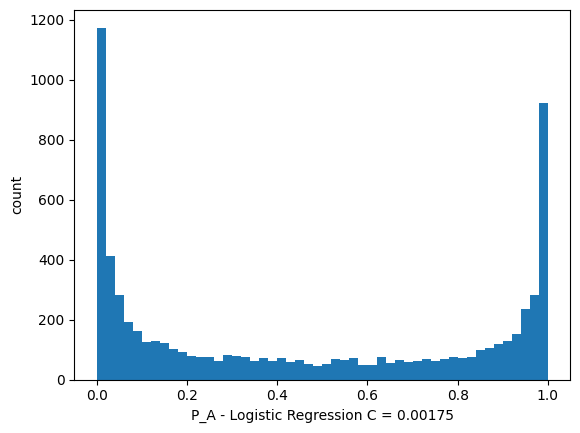

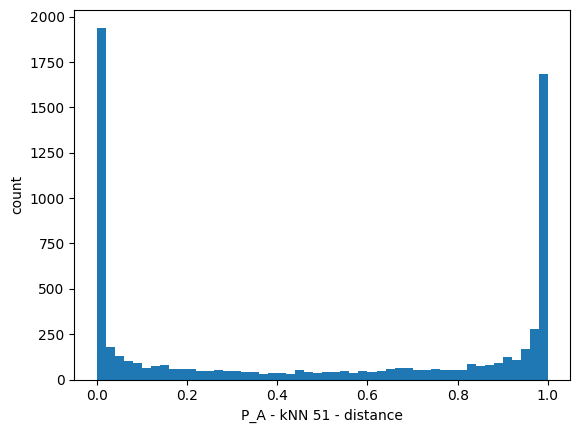

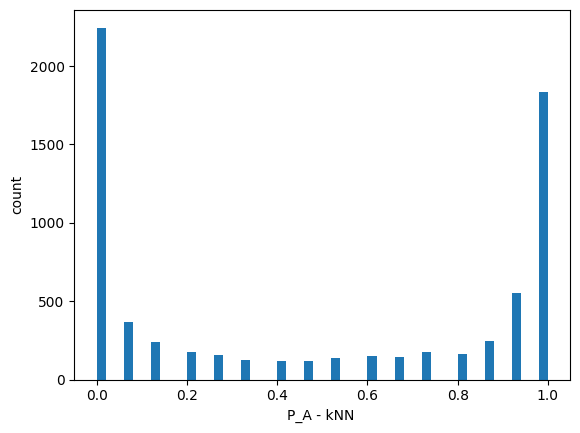

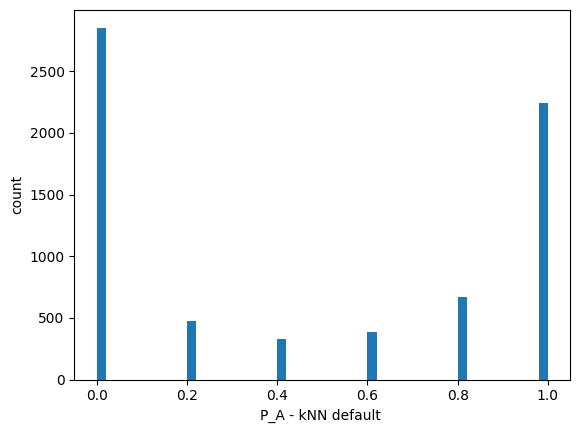

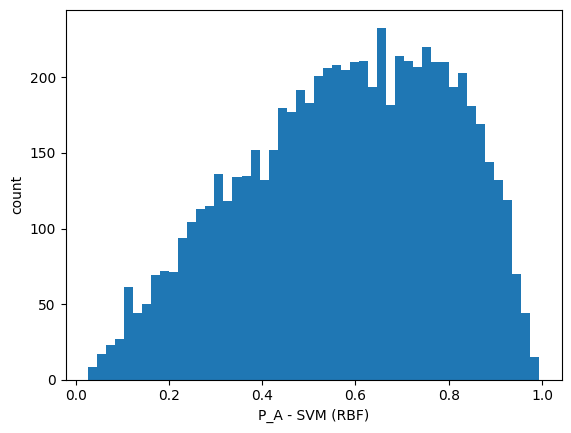

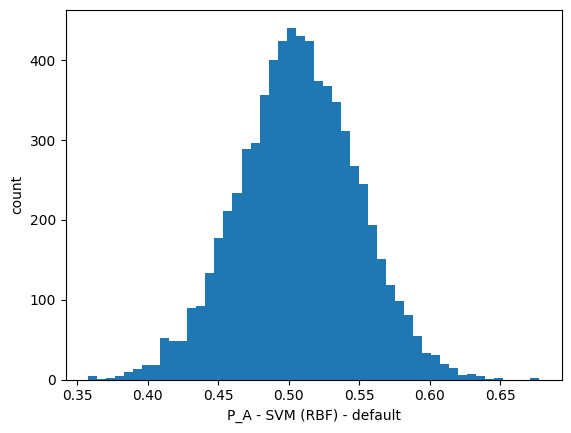

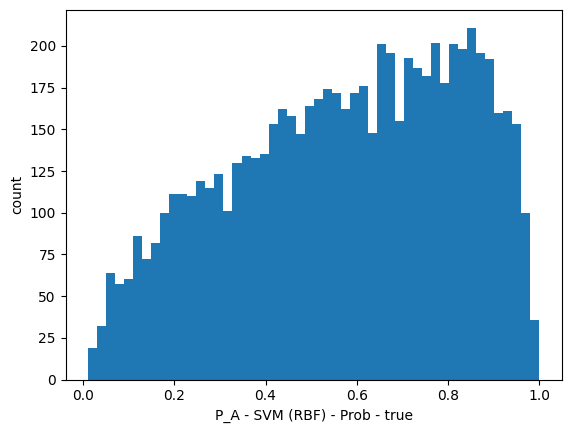

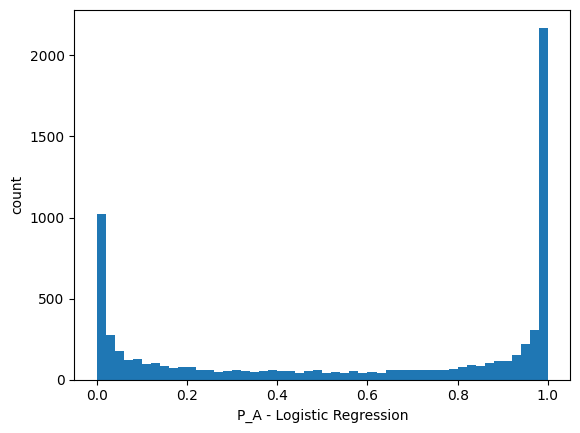

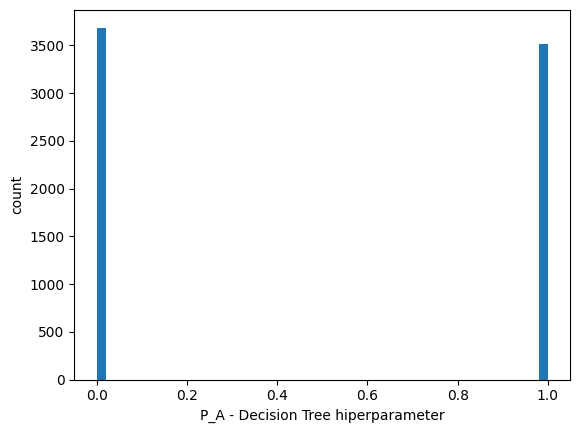

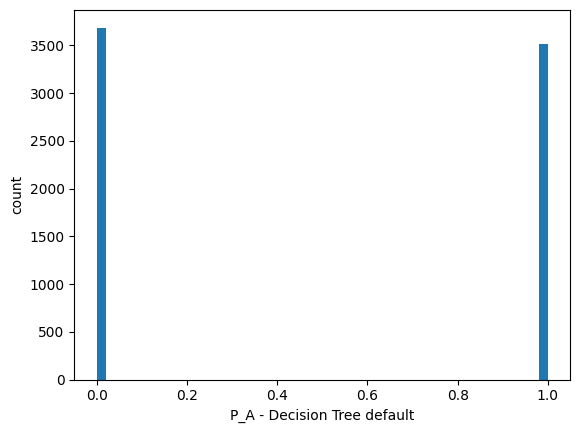

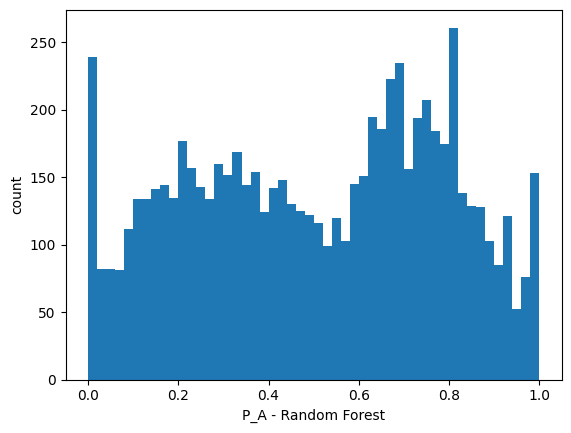

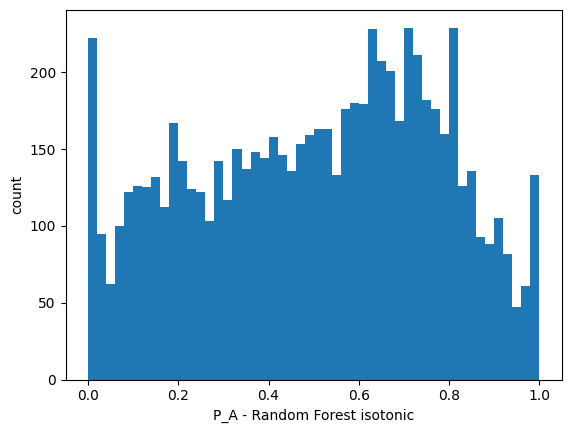

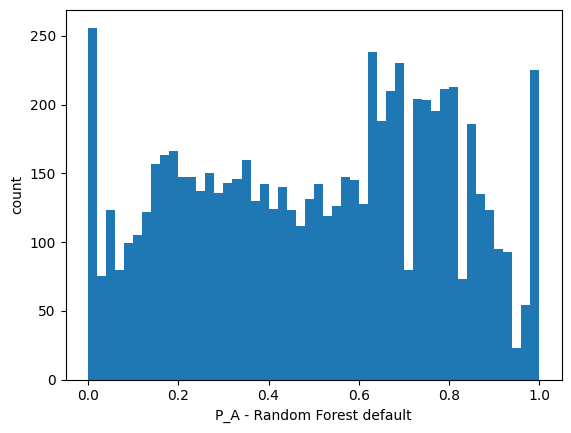

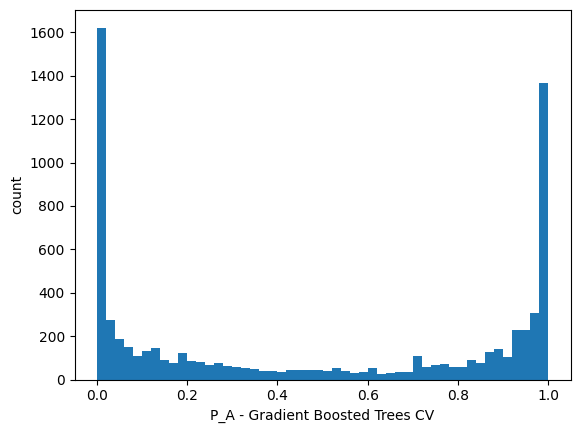

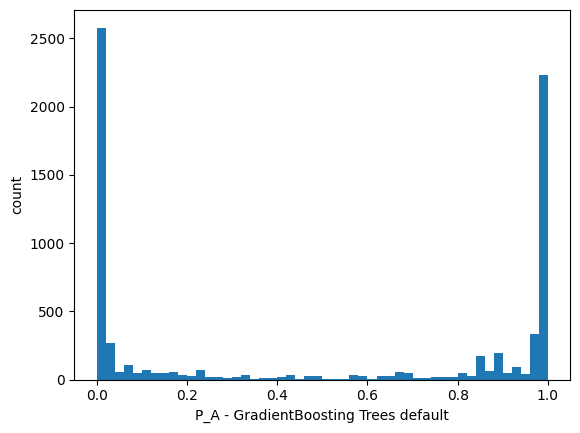

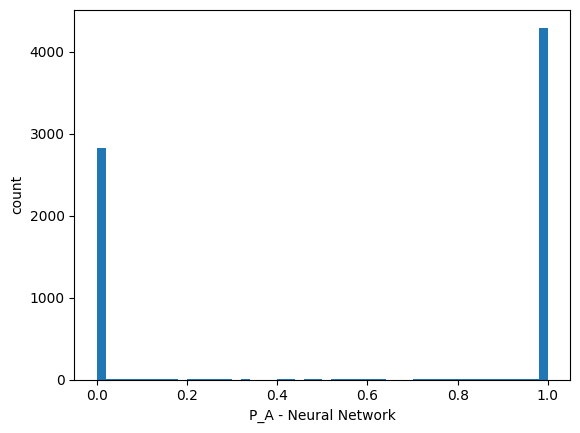

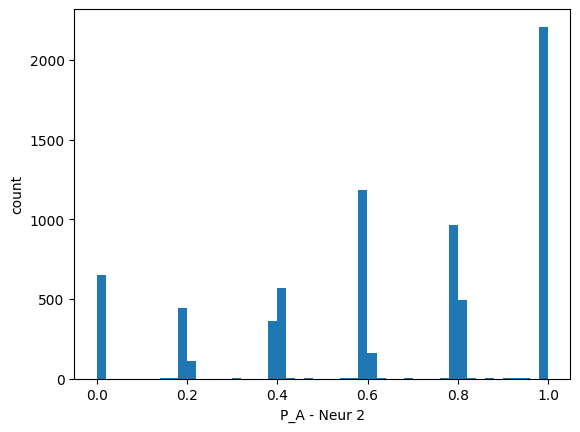

In [10]:
for dupa, model in zip(P_A_all, P_A_models):
    plt.hist(dupa, bins=50)
    plt.xlabel(f"P_A - {model}")
    plt.ylabel("count")
    plt.show()

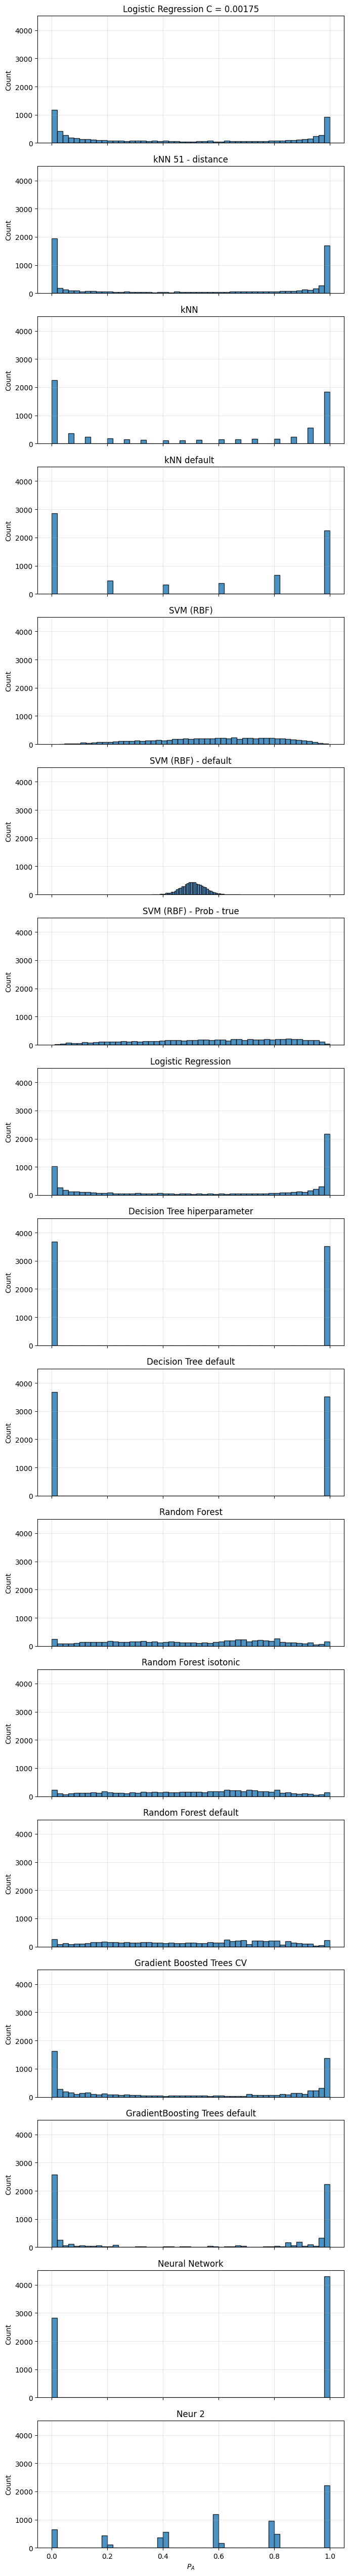

In [11]:
fig, axes = plt.subplots(
    nrows=len(P_A_all),
    figsize=(7, 3 * len(P_A_all)),
    sharex=True,
    sharey=True
)

for ax, data, model in zip(axes, P_A_all, P_A_models):
    ax.hist(data, bins=50, edgecolor="black", alpha=0.8)
    ax.set_title(model)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel(r"$P_A$")

plt.tight_layout()
plt.show()

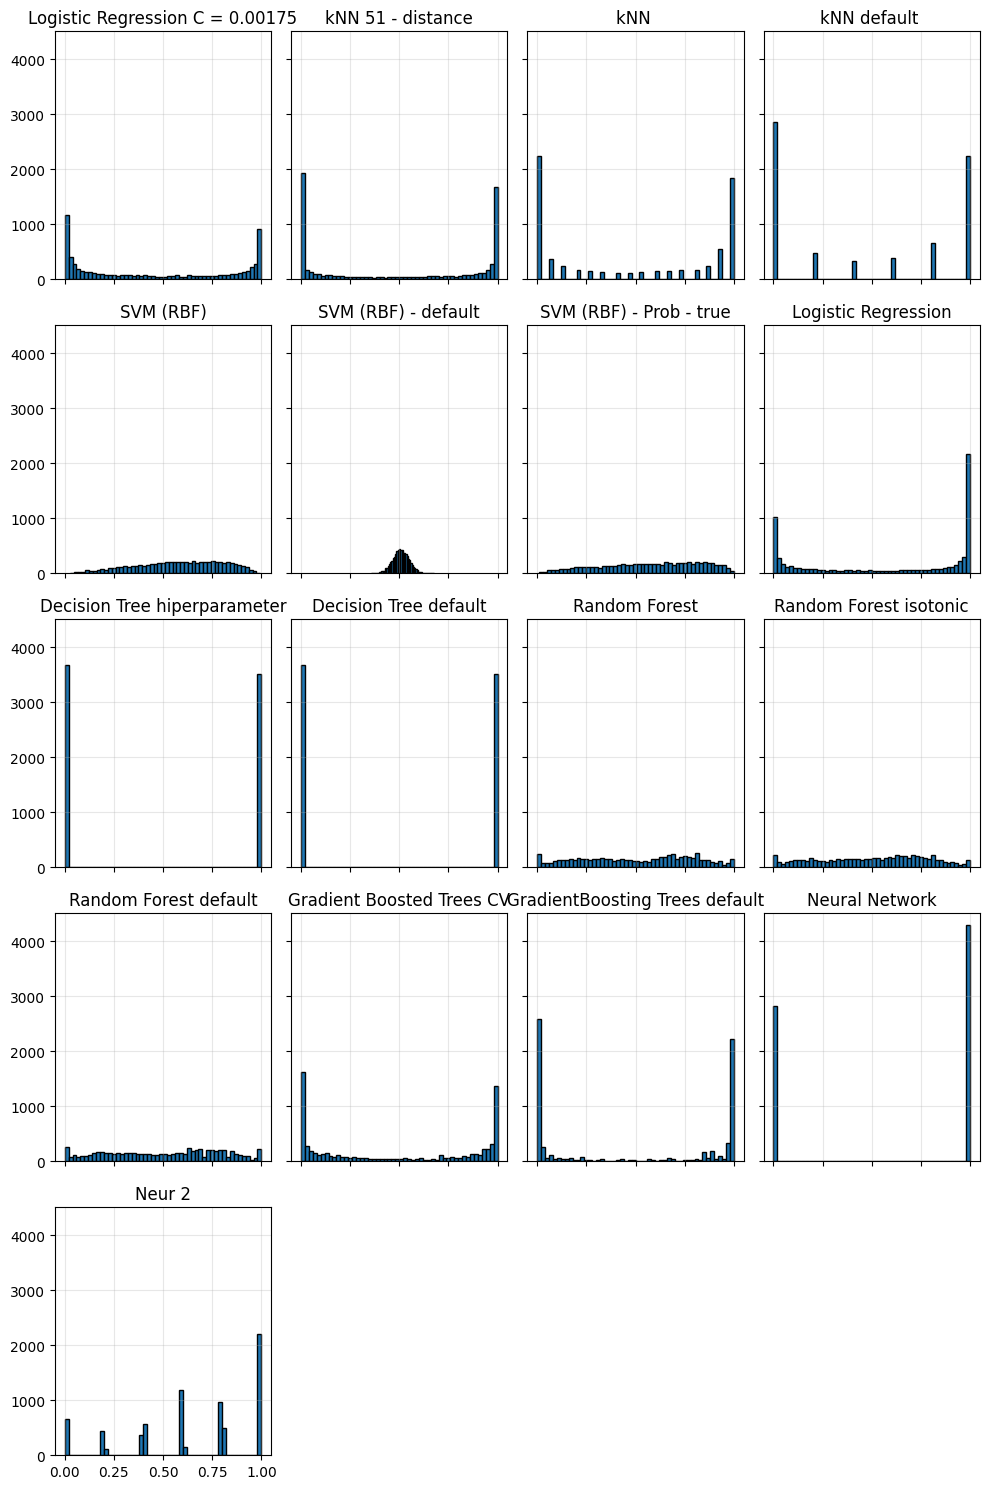

In [12]:
import math

n = len(P_A_all)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(10, 3 * rows),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for ax, data, model in zip(axes, P_A_all, P_A_models):
    ax.hist(data, bins=50, edgecolor="black")
    ax.set_title(model)
    ax.grid(alpha=0.3)

# usuń puste osie
for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()

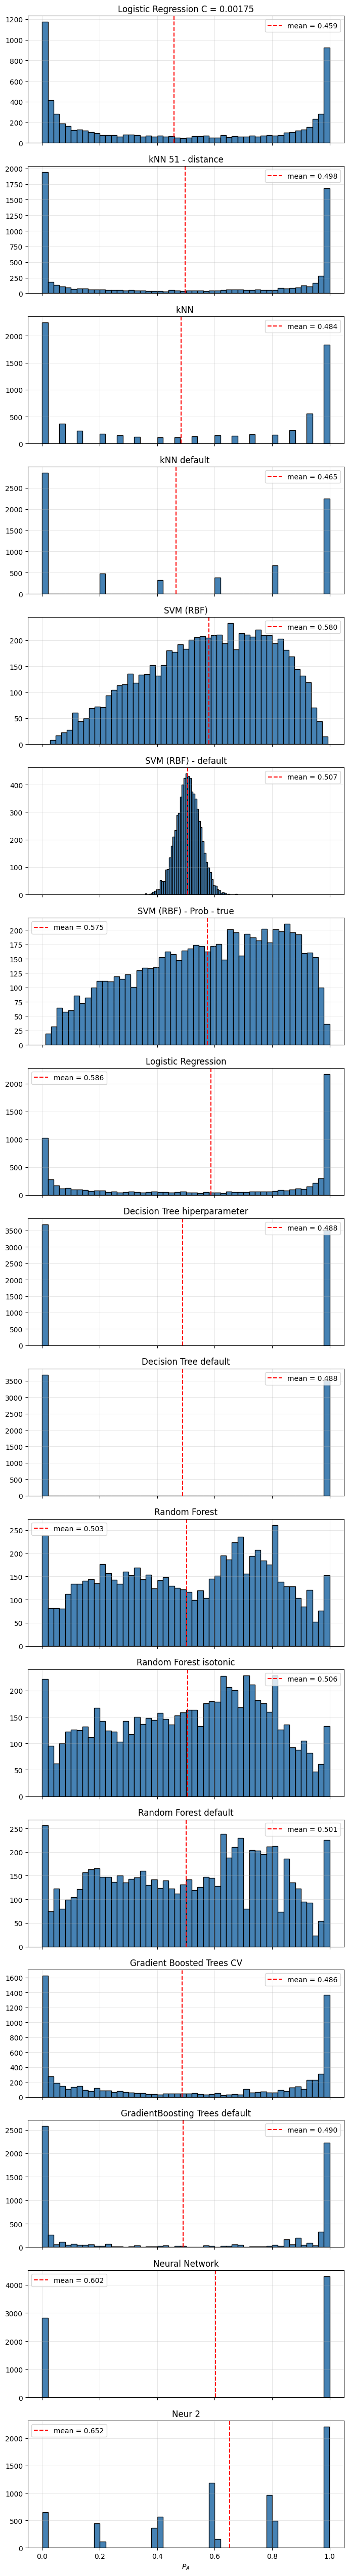

In [13]:
fig, axes = plt.subplots(
    len(P_A_all),
    1,
    figsize=(7, 3 * len(P_A_all)),
    sharex=True
)

for ax, data, model in zip(axes, P_A_all, P_A_models):
    ax.hist(data, bins=50, color="steelblue", edgecolor="black")
    ax.axvline(np.mean(data), color="red", ls="--",
               label=f"mean = {np.mean(data):.3f}")
    ax.set_title(model)
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel(r"$P_A$")
plt.tight_layout()
plt.show()

In [14]:
# import matplotlib.pyplot as plt
# import math

# C_values = [0.001, 0.0015, 0.00175, 0.002, 0.00225, 1]

# n = len(P_A_all)

# cols = 3
# rows = math.ceil(n / cols)

# fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
# axes = axes.flatten()

# for i, dupa in enumerate(P_A_all):
#     axes[i].hist(dupa, bins=50)
#     axes[i].set_title(f"Logistic Regression (C={C_values[i]})")
#     axes[i].set_xlabel("P_A")
#     axes[i].set_ylabel("count")

# # usuń puste osie
# for j in range(len(P_A_all), len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.savefig("all_histograms.png", dpi=300)
# plt.show()